In [10]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("dataset/ai4i2020.csv")
print("Dataset Shape:", df.shape)
df.head()
df.info()

Dataset Shape: (10000, 14)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: floa

Machine failure
0    9661
1     339
Name: count, dtype: int64


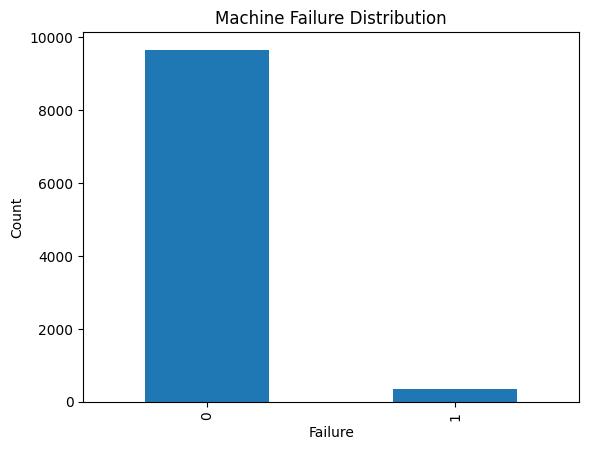

In [11]:
failure_counts = df["Machine failure"].value_counts()
print(failure_counts)
failure_counts.plot(kind='bar')
plt.title("Machine Failure Distribution")
plt.xlabel("Failure")
plt.ylabel("Count")
plt.show()

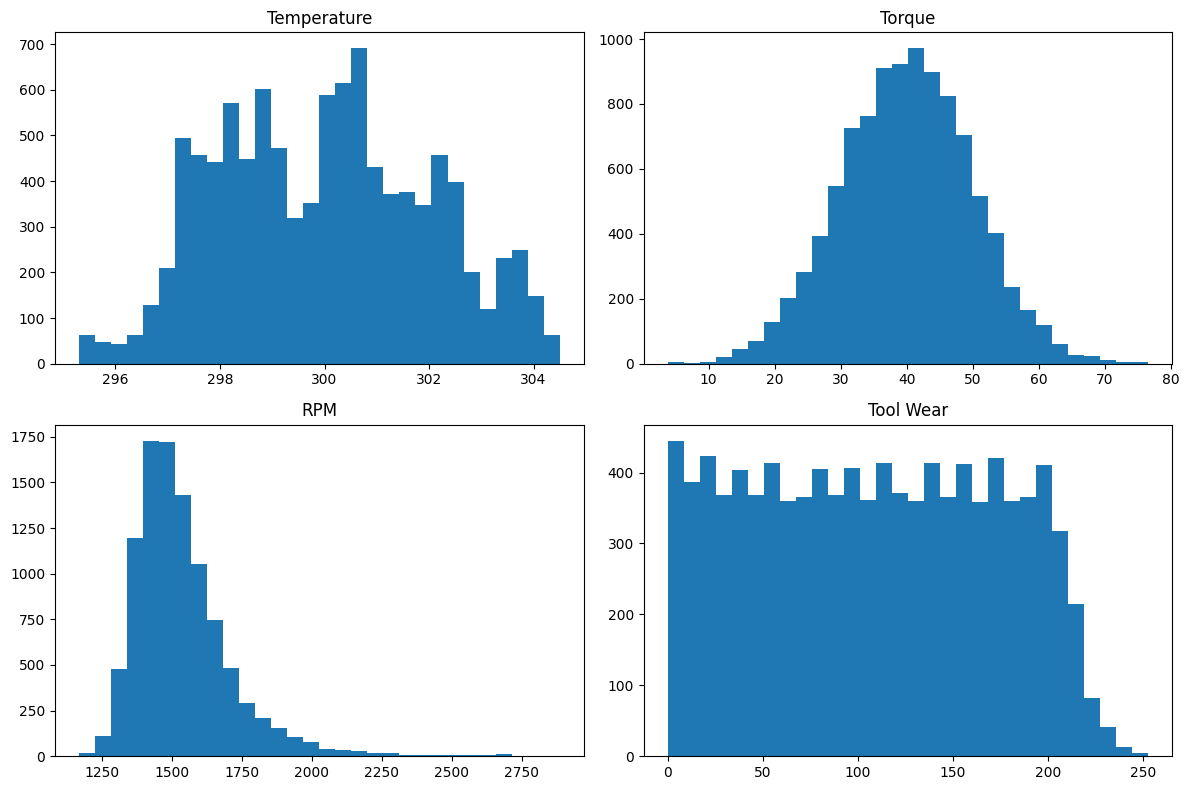

In [12]:
plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
plt.hist(df['Air temperature [K]'], bins=30)
plt.title('Temperature')
plt.subplot(2,2,2)
plt.hist(df['Torque [Nm]'], bins=30)
plt.title('Torque')
plt.subplot(2,2,3)
plt.hist(df['Rotational speed [rpm]'], bins=30)
plt.title('RPM')
plt.subplot(2,2,4)
plt.hist(df['Tool wear [min]'], bins=30)
plt.title('Tool Wear')
plt.tight_layout()
plt.show()

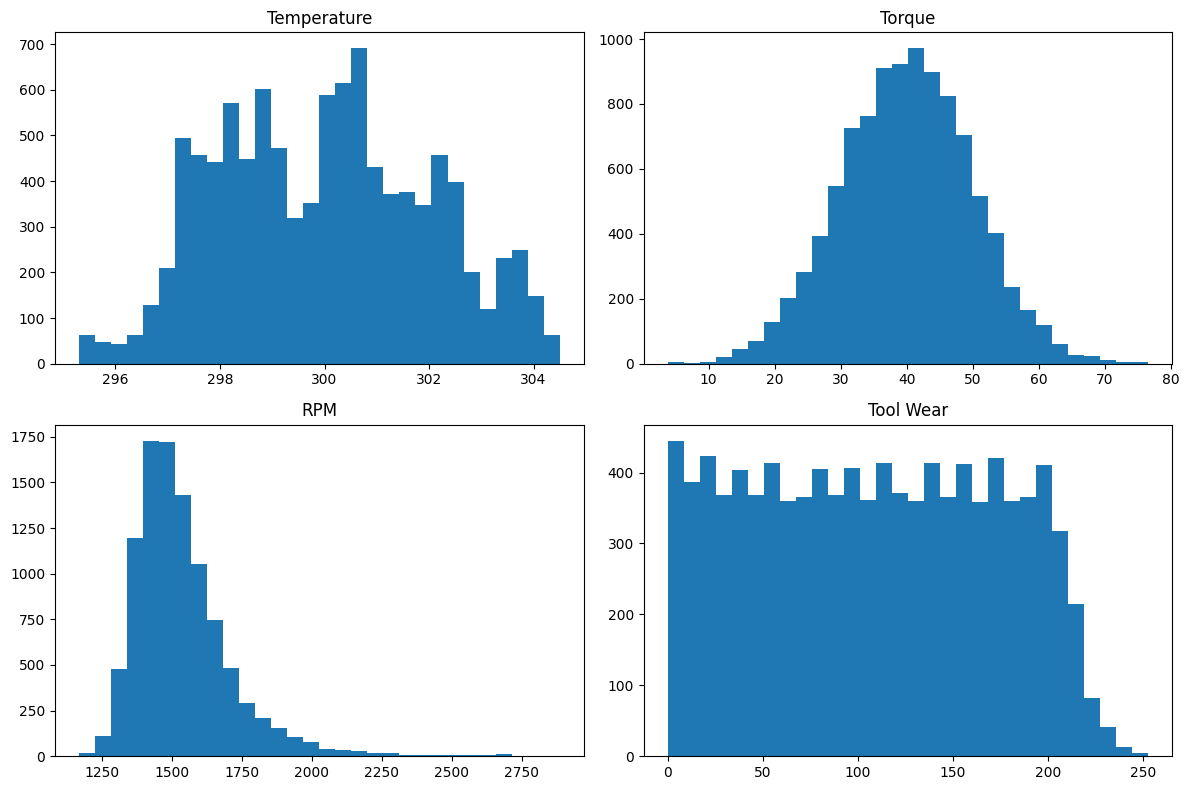

In [13]:
plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
plt.hist(df['Air temperature [K]'], bins=30)
plt.title('Temperature')
plt.subplot(2,2,2)
plt.hist(df['Torque [Nm]'], bins=30)
plt.title('Torque')
plt.subplot(2,2,3)
plt.hist(df['Rotational speed [rpm]'], bins=30)
plt.title('RPM')
plt.subplot(2,2,4)
plt.hist(df['Tool wear [min]'], bins=30)
plt.title('Tool Wear')
plt.tight_layout()
plt.show()

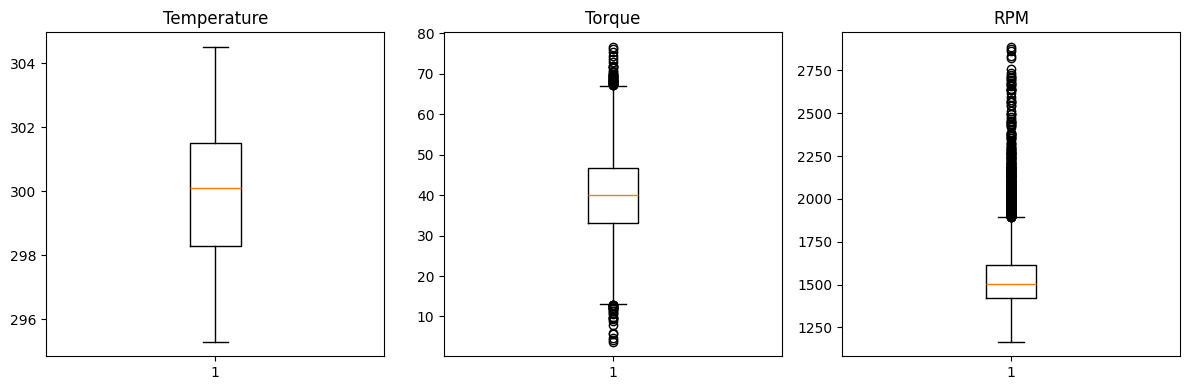

In [14]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.boxplot(df['Air temperature [K]'])
plt.title('Temperature')
plt.subplot(1,3,2)
plt.boxplot(df['Torque [Nm]'])
plt.title('Torque')
plt.subplot(1,3,3)
plt.boxplot(df['Rotational speed [rpm]'])
plt.title('RPM')
plt.tight_layout()
plt.show()

In [15]:
numerical_df = df.select_dtypes(include=['int64','float64'])
correlation_matrix = numerical_df.corr()
correlation_matrix

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
UDI,1.000000,0.117428,0.324428,-0.006615,0.003207,-0.010702,-0.022892,0.009154,-0.022215,-0.023557,-0.000990,-0.005954
Air temperature [K],0.117428,1.000000,0.876107,0.022670,-0.013778,0.013853,0.082556,0.009955,0.137831,0.003470,0.001988,0.017688
Process temperature [K],0.324428,0.876107,1.000000,0.019277,-0.014061,0.013488,0.035946,0.007315,0.056933,-0.003355,0.004554,0.022279
Rotational speed [rpm],-0.006615,0.022670,0.019277,1.000000,-0.875027,0.000223,-0.044188,0.010389,-0.121241,0.123018,-0.104575,-0.013088
Torque [Nm],0.003207,-0.013778,-0.014061,-0.875027,1.000000,-0.003093,0.191321,-0.014662,0.142610,0.083781,0.183465,0.016136
Tool wear [min],-0.010702,0.013853,0.013488,0.000223,-0.003093,1.000000,0.105448,0.115792,-0.001287,-0.009334,0.155894,0.011326
Machine failure,-0.022892,0.082556,0.035946,-0.044188,0.191321,0.105448,1.000000,0.362904,0.575800,0.522812,0.531083,0.004516
TWF,0.009154,0.009955,0.007315,0.010389,-0.014662,0.115792,0.362904,1.000000,-0.007332,0.008577,0.038243,0.030970
HDF,-0.022215,0.137831,0.056933,-0.121241,0.142610,-0.001287,0.575800,-0.007332,1.000000,0.018443,0.046396,-0.004706
PWF,-0.023557,0.003470,-0.003355,0.123018,0.083781,-0.009334,0.522812,0.008577,0.018443,1.000000,0.115836,-0.004273


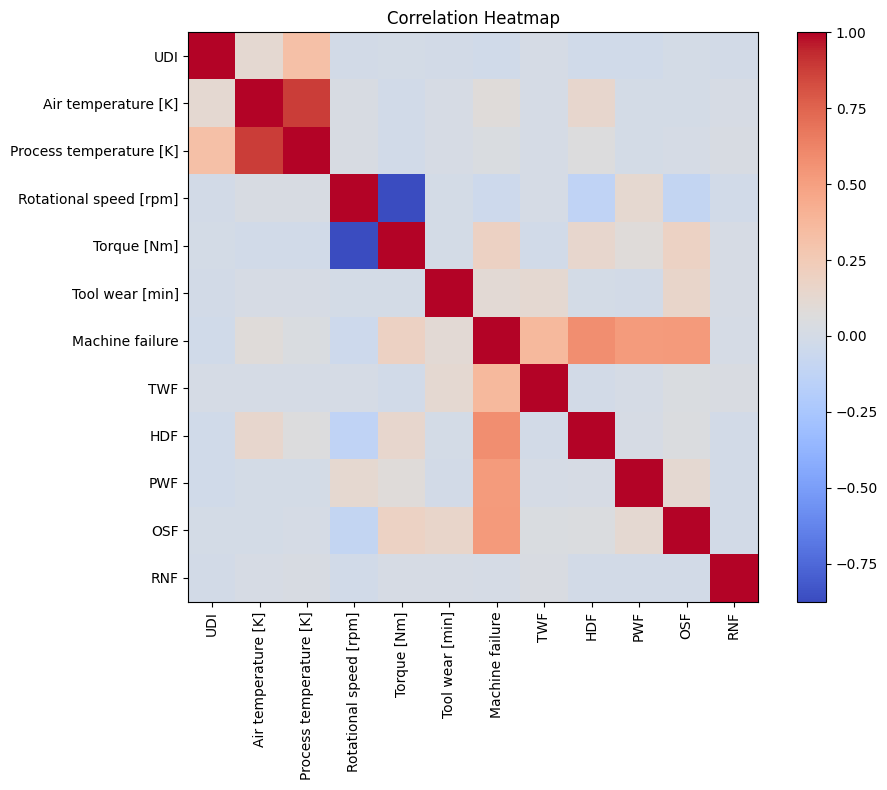

In [16]:
plt.figure(figsize=(10,8))
plt.imshow(correlation_matrix,
           cmap='coolwarm',
           interpolation='nearest')
plt.colorbar()
plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)
plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [17]:
correlation_matrix["Machine failure"].sort_values(ascending=False)

Machine failure            1.000000
HDF                        0.575800
OSF                        0.531083
PWF                        0.522812
TWF                        0.362904
Torque [Nm]                0.191321
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Process temperature [K]    0.035946
RNF                        0.004516
UDI                       -0.022892
Rotational speed [rpm]    -0.044188
Name: Machine failure, dtype: float64

In [18]:
summary = pd.DataFrame({
    "Task":[
        "EDA",
        "Sensor Analysis",
        "Outlier Analysis",
        "Correlation Analysis"
    ],
    "Status":[
        "Completed",
        "Completed",
        "Completed",
        "Completed"
    ]
})
summary

,Task,Status
0,EDA,Completed
1,Sensor Analysis,Completed
2,Outlier Analysis,Completed
3,Correlation Analysis,Completed
